<h1>Natural Language Processing with Disaster Tweets</h1>

<a id = 'intro'></a>
# Goal
<br>
Predict which Tweets are about real disasters and which ones are not

# 1. Import Libraries and data

In [3]:
import numpy as np 
import pandas as pd
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

In [4]:
sample = pd.read_csv("nlp-getting-started/sample_submission.csv")
sample.head()

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


In [5]:
# Get info on the training data
train_data = pd.read_csv("nlp-getting-started/train.csv")
train_data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [7]:
# Get the columns' names on the train data
train_data.columns

Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')

In [8]:
# Get the train data structure's shape
train_data.shape

(7613, 5)

In [9]:
train_data.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [10]:
# Get general info on train data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [11]:
# Get the count of unique values on train dataset
train_data.nunique()

id          7613
keyword      221
location    3341
text        7503
target         2
dtype: int64

In [12]:
# Get descriptive statistics on train_data
train_data.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


Now, get information on the test data. 

In [14]:
# Get info on the test data
test_data = pd.read_csv("nlp-getting-started/test.csv")
test_data.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [15]:
test_data.columns

Index(['id', 'keyword', 'location', 'text'], dtype='object')

In [16]:
test_data.shape

(3263, 4)

In [17]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB


In [18]:
# Check on the number of unique elements
test_data.nunique()

id          3263
keyword      221
location    1602
text        3243
dtype: int64

In [19]:
# Get descriptive statistics on the test data
test_data.describe()

,id
count,3263.000000
mean,5427.152927
std,3146.427221
min,0.000000
25%,2683.000000
50%,5500.000000
75%,8176.000000
max,10875.000000


In [20]:
# Compare the train and test data info and shapes
print(train_data.info(), test_data.info())
print(train_data.shape, test_data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB
None None
(7613, 5) (3263, 4)


In [21]:
# Remove the columns location, id from test_data; not necessary
test_data = test_data.loc[:, ['keyword', 'text']]
test_data

,keyword,text
0,NaN,Just happened a terrible car crash
1,NaN,"Heard about #earthquake is different cities, s..."
2,NaN,"there is a forest fire at spot pond, geese are..."
3,NaN,Apocalypse lighting. #Spokane #wildfires
4,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...
3258,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,NaN,Storm in RI worse than last hurricane. My city...
3260,NaN,Green Line derailment in Chicago http://t.co/U...
3261,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [22]:
# Get more info on train_data
print(train_data.columns)
train_data

Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [23]:
len(train_data[train_data['keyword'].isna()])

61

In [24]:
len(train_data[train_data['location'].isnull() | train_data['location'].isna()])

2533

In [25]:
# Goal of the project is to match tweets with intended target (disastorous tweet marked 1; 0 otherwise)
# Drop the id and location columns from the train_data frame
train_data = train_data.loc[:, ['keyword', 'text', 'target']]
train_data

,keyword,text,target
0,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,NaN,Forest fire near La Ronge Sask. Canada,1
2,NaN,All residents asked to 'shelter in place' are ...,1
3,NaN,"13,000 people receive #wildfires evacuation or...",1
4,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...
7608,NaN,Two giant cranes holding a bridge collapse int...,1
7609,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,NaN,Police investigating after an e-bike collided ...,1


In [26]:
train_data['keyword'].value_counts()

keyword
fatalities               45
deluge                   42
armageddon               42
sinking                  41
damage                   41
                         ..
forest%20fire            19
epicentre                12
threat                   11
inundation               10
radiation%20emergency     9
Name: count, Length: 221, dtype: int64

In [27]:
test_data['keyword'].value_counts()

keyword
deluged               23
demolished            22
rubble                22
first%20responders    21
seismic               21
                      ..
threat                 5
fatalities             5
forest%20fire          5
inundation             4
epicentre              1
Name: count, Length: 221, dtype: int64

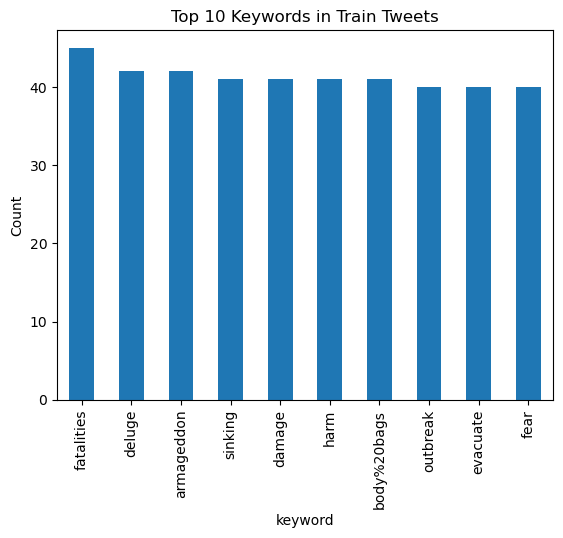

In [28]:
train_data['keyword'].value_counts().head(10).plot.bar()
plt.title("Top 10 Keywords in Train Tweets")
plt.ylabel("Count")
plt.show()

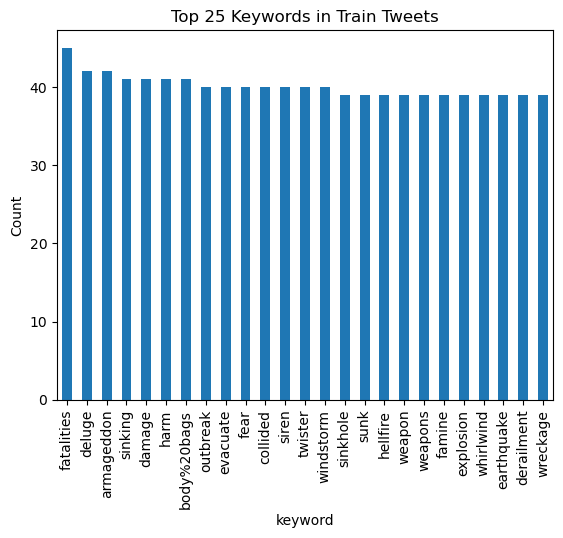

In [29]:
train_data['keyword'].value_counts().head(25).plot.bar()
plt.title("Top 25 Keywords in Train Tweets")
plt.ylabel("Count")
plt.show()

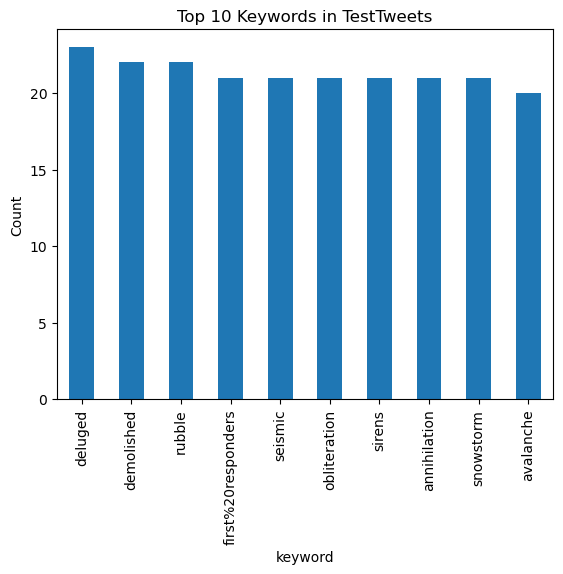

In [30]:
# A plot of the test data
test_data['keyword'].value_counts().head(10).plot.bar()
plt.title("Top 10 Keywords in TestTweets")
plt.ylabel("Count")
plt.show()

In [31]:
train_data['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

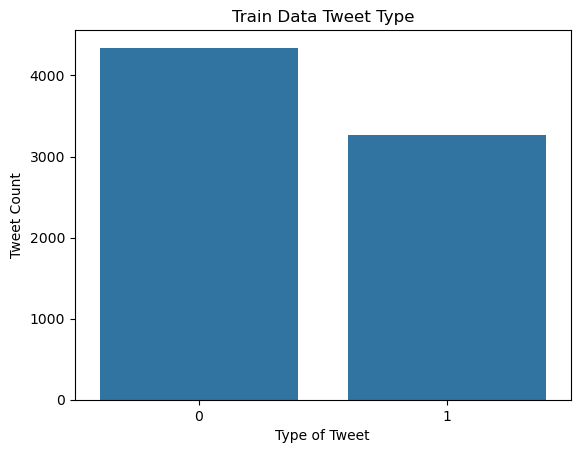

In [32]:
sns.countplot(train_data, x='target')
plt.xlabel("Type of Tweet")
plt.ylabel("Tweet Count")
plt.title("Train Data Tweet Type")
plt.show()


# Data Preparation & Preprocessing


In [34]:

import re
import emoji
# !pip install contractions
import contractions
import html

# Create function to clean up the tweets to be plain text
def get_clean_tweets(text):
    
    # Rid the tweets of any extra spaces leading or following the first or last word
    text = text.strip()
    
    # Convert HTML entities
    text = html.unescape(text)
    
    # Fix corrupted Unicode artifacts
    text = text.replace("‰ÛÏ", '"').replace("‰Û", '"')  # Fix double quotes
    text = text.replace("‰Û÷", "'").replace("‰Ûª", "'")  # Fix single quotes
    text = text.replace("‰Û¢", "-").replace("‰Û_", "-")  # Fix hyphen issues
    
    # Remove any remaining corrupted symbols
    text = re.sub(r"[^\x00-\x7F]+", "", text)  # Remove remaining non-ASCII characters
    
    # Remove URLs that start with 'https://...' or any links
    text = re.sub(r'http\S+', '', text)
    
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove any emojis - had no idea that there was a library that could get this done
    text = emoji.demojize(text, delimiters=(" ", " "))  
    
    # Expand contractions
    text = contractions.fix(text)

    return text


In [35]:
# Apply to both train and test tweets columns in datasets
train_data['text'] = train_data['text'].apply(get_clean_tweets)
test_data['text'] = test_data['text'].apply(get_clean_tweets)

In [36]:
train_data['text']

0       Our Deeds are the Reason of this #earthquake M...
1                  Forest fire near La Ronge Sask. Canada
2       All residents asked to 'shelter in place' are ...
3       13,000 people receive #wildfires evacuation or...
4       Just got sent this photo from Ruby #Alaska as ...
                              ...                        
7608    Two giant cranes holding a bridge collapse int...
7609      The out of control wild fires in California ...
7610          M1.94 [01:04 UTC]?5km S of Volcano Hawaii. 
7611    Police investigating after an e-bike collided ...
7612    The Latest: More Homes Razed by Northern Calif...
Name: text, Length: 7613, dtype: object

In [37]:
test_data['text']

0                      Just happened a terrible car crash
1       Heard about #earthquake is different cities, s...
2       there is a forest fire at spot pond, geese are...
3                Apocalypse lighting. #Spokane #wildfires
4           Typhoon Soudelor kills 28 in China and Taiwan
                              ...                        
3258    EARTHQUAKE SAFETY LOS ANGELES  SAFETY FASTENER...
3259    Storm in RI worse than last hurricane. My city...
3260                    Green Line derailment in Chicago 
3261          MEG issues Hazardous Weather Outlook (HWO) 
3262    #CityofCalgary has activated its Municipal Eme...
Name: text, Length: 3263, dtype: object

In [40]:
# Import the appropriate libraries to split up the training data
import tensorflow as tf
import keras
import keras_nlp
from keras import layers
from keras.layers import TextVectorization
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [42]:
# Set batch size and get the text column for x; target column for y
BATCH_SIZE = 16
RANDOM_STATE = 101

x = train_data['text']
y = train_data['target']

In [44]:
# Split up the data into train and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)

x_test = test_data['text']

In [45]:
len(x), len(y)

(7613, 7613)

In [46]:
print(len(x_train), len(y_train), len(x_valid), len(y_valid))

6090 6090 1523 1523


In [48]:
x_train.shape

(6090,)

<a id='Model'></a>
# Training the Model

Now, time to train the model. <br>
Re-compile the data, optimize the model, and then fit the data into the model. 

In [50]:

preset= "distil_bert_base_en_uncased"

# Use a shorter sequence length - 140
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(preset,
                                                                   sequence_length=140,
                                                                   name="preprocessor_4_tweets"
                                                                  )

# Pretrain the classifier for model
classifier = keras_nlp.models.DistilBertClassifier.from_preset(preset,preprocessor = preprocessor, 
                                                               num_classes=2)

classifier.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Re-compile data with different learning rate

classifier.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  optimizer=keras.optimizers.Adam(1e-5),
                  metrics=['accuracy'])

In [52]:

# Fit the data into the model
# Set number of epochs to 10
model = classifier.fit(x=x_train, 
          y=y_train,
          batch_size=BATCH_SIZE,
       validation_data=(x_valid,y_valid),
           epochs=10
)

Epoch 1/10


2025-09-21 11:48:56.311967: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


381/381 ━━━━━━━━━━━━━━━━━━━━ 265s 669ms/step - accuracy: 0.7200 - loss: 0.5362 - val_accuracy: 0.8378 - val_loss: 0.3899
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 262s 687ms/step - accuracy: 0.8535 - loss: 0.3602 - val_accuracy: 0.8391 - val_loss: 0.3943
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 249s 653ms/step - accuracy: 0.8800 - loss: 0.3174 - val_accuracy: 0.8385 - val_loss: 0.4078
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 247s 648ms/step - accuracy: 0.8988 - loss: 0.2685 - val_accuracy: 0.8319 - val_loss: 0.4164
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.9176 - loss: 0.2298 - val_accuracy: 0.8260 - val_loss: 0.4789
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 253s 663ms/step - accuracy: 0.9285 - loss: 0.1917 - val_accuracy: 0.8260 - val_loss: 0.5418
Epoch 7/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 246s 645ms/step - accuracy: 0.9389 - loss: 0.1619 - val_accuracy: 0.8221 - val_loss: 0.6110
Epoch 8/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 247s 648ms/step - accuracy: 0.9434 - loss: 0.1435 

In [53]:
# Get logs - a full dictionary
print(model.history)

{'accuracy': [0.7926108241081238, 0.8625615835189819, 0.8889983296394348, 0.911494255065918, 0.9292282462120056, 0.9407225251197815, 0.9499179124832153, 0.9546797871589661, 0.9663382768630981, 0.969786524772644], 'loss': [0.45591986179351807, 0.34510961174964905, 0.2958768606185913, 0.24332667887210846, 0.20039454102516174, 0.16329865157604218, 0.13498586416244507, 0.11734973639249802, 0.08820480108261108, 0.07234002649784088], 'val_accuracy': [0.8378201127052307, 0.8391332626342773, 0.8384767174720764, 0.8319107294082642, 0.8260012865066528, 0.8260012865066528, 0.8220617175102234, 0.8148391246795654, 0.813525915145874, 0.7977675795555115], 'val_loss': [0.38988861441612244, 0.39433929324150085, 0.40777572989463806, 0.4164174199104309, 0.478946328163147, 0.5417616963386536, 0.6110390424728394, 0.6470019221305847, 0.739616334438324, 0.8330784440040588]}


In [54]:
# Get keys to save the training and validation logs percentages for each epoch
model.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [55]:
# number of values in each list should align to how many epochs were needed to train
loss = model.history['loss']
val_loss = model.history['val_loss']
accuracy = model.history['accuracy']
val_accuracy = model.history['val_accuracy']
print(len(loss), type(loss))

10 <class 'list'>


<a id='Plots'></a>
# Plotting Loss
Gather all the information from model's history and plot the curves to see how the training data did against the validation data. 

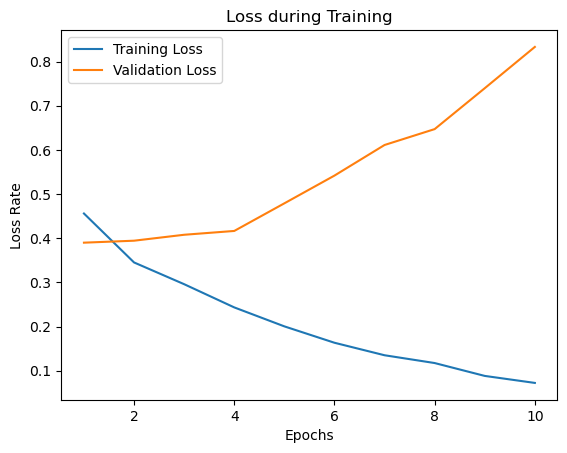

In [56]:
# Initialize x-axis for plots - first plot the loss
epochs = list(range(1, len(loss) + 1))

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title("Loss during Training")
plt.xlabel("Epochs")
plt.ylabel("Loss Rate")
plt.legend()
plt.show()

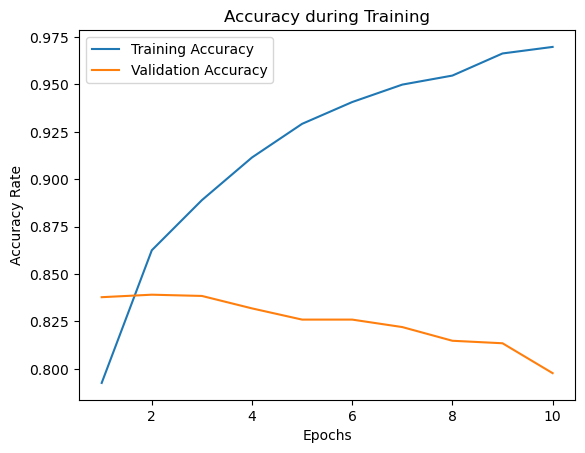

In [57]:
# Now plot the accuracy
plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title("Accuracy during Training")
plt.xlabel("Epochs")
plt.ylabel("Accuracy Rate")
plt.legend()
plt.show()

In [58]:
# Generate Confusion Matrix
def getConfusionMatrix(y_true, y_pred, data):
    matr = ConfusionMatrixDisplay.from_predictions(y_true, np.argmax(y_pred, axis=1),
                                                  display_labels=['Not Disaster Tweet', 'Disaster Tweet'])
    true_neg, false_pos, false_neg, true_pos = confusion_matrix(y_true, np.argmax(y_pred, axis=1)).ravel()
    precision = true_pos / (true_pos + false_pos)
    recall = true_pos / (true_pos + false_neg)
    f1 = 2 * ( (precision * recall) / (precision + recall))
    matr.ax_.set_title("Confusion Matrix on " + data + " Dataset -- F1 Score: " + str(f1.round(3)))
    print(precision, recall)


In [59]:
# Predict model on x_train 
y_pred_train = classifier.predict(x_train)

191/191 ━━━━━━━━━━━━━━━━━━━━ 72s 375ms/step


0.9755271084337349 0.981439393939394


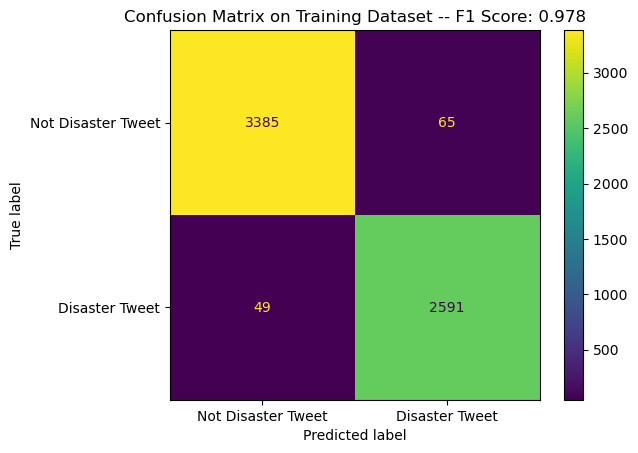

In [60]:
# Display the Confusion Matrix for training data
getConfusionMatrix(y_train, y_pred_train, "Training")

In [61]:
# Predict model on x_val 
y_pred_valid = classifier.predict(x_valid)

48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 374ms/step


0.7503875968992249 0.7670364500792393


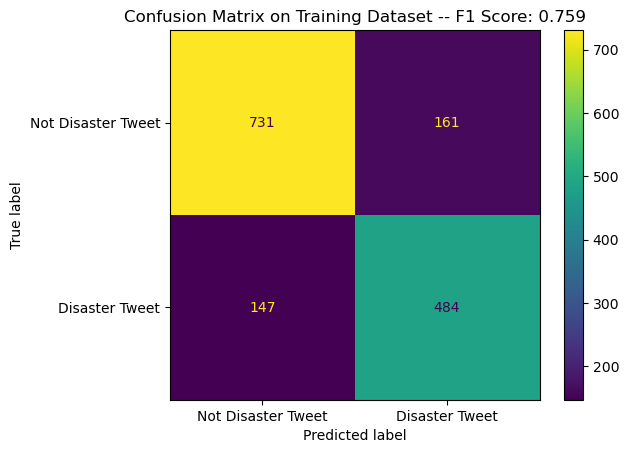

In [62]:
# Display the Confusion Matrix for the validation data
getConfusionMatrix(y_valid, y_pred_valid, "Training")

In [63]:
# Check the sample submission file
sample

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


<a id='Conclusion'></a>
# Conclusion and Submission

It can be seen from the confusion matrices that we received some levels of accuracy running the preprocessing and modeling through DistilBERT. <br>
The F1 score received for the training data was 0.98, and the validation data 0.75, provided that the validation set was smaller than the training set. <br>
There was not much training loss between any of the epochs, as it stayed well below 10% most of the time. <br>
It can also be seen that there were a couple of sharp periods of increases when it came to the validation loss. <br>
As for the modeling accuracy, the training rate stayed well above 95%, while the validation data model epochs runs ranged anywhere from 79% to 82%. <br>
In the validation prediction confusion matrix, there was an equal number of false negative and false positive predictions with 150 and 158, respectively. <br>



In [64]:
# Alter the submission file column target with the predictions to submit
# Use x_test data for the prediction
sample['target'] = np.argmax(classifier.predict(x_test), axis=1)

102/102 ━━━━━━━━━━━━━━━━━━━━ 38s 375ms/step


In [65]:
sample.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


In [66]:
sample.describe()

,id,target
count,3263.000000,3263.000000
mean,5427.152927,0.416794
std,3146.427221,0.493104
min,0.000000,0.000000
25%,2683.000000,0.000000
50%,5500.000000,0.000000
75%,8176.000000,1.000000
max,10875.000000,1.000000


In [67]:
# Create new submission CSV file - submit to 'submission.csv'
sample.to_csv('submission.csv', index=False)